In [1]:
import torch
import requests
import numpy as np

from io import BytesIO
from PIL import Image
# from torch.nn.parallel import DataParallel as DP
from captum.attr import LayerIntegratedGradients, LLMGradientAttribution, TextTokenInput
# from accelerate import dispatch_model, infer_auto_device_map
# from accelerate.utils import get_balanced_memory

from share4v.constants import (DEFAULT_IM_END_TOKEN, DEFAULT_IM_START_TOKEN,
                               DEFAULT_IMAGE_TOKEN, IMAGE_TOKEN_INDEX)
from share4v.conversation import SeparatorStyle, conv_templates
from share4v.mm_utils import get_model_name_from_path, tokenizer_image_token, KeywordsStoppingCriteria
from share4v.model.builder import load_pretrained_model
from share4v.utils import disable_torch_init

/home/lcorti/miniconda3/envs/lmms/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_image(image_file):
    if image_file.startswith('http') or image_file.startswith('https'):
        response = requests.get(image_file)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(image_file).convert('RGB')
    return image

def format_query(q, model):
    if model.config.mm_use_im_start_end:
        qs = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + \
            DEFAULT_IM_END_TOKEN + '\n' + q
    else:
        qs = DEFAULT_IMAGE_TOKEN + '\n' + q
    
    return qs

def set_conv_mode(model_name):
    if 'llama-2' in model_name.lower():
        conv_mode = "share4v_llama_2"
    elif "v1" in model_name.lower():
        conv_mode = "share4v_v1"
    elif "mpt" in model_name.lower():
        conv_mode = "mpt"
    else:
        conv_mode = "share4v_v0"
    
    return conv_mode

def get_conv_template(conv_mode):
    return conv_templates[conv_mode].copy()

def get_stop_str(conv):
    return conv.sep if conv.sep_style != SeparatorStyle.TWO else conv.sep2

def get_stopping_criteria(input_ids, stop_str, tokenizer):
    keywords = [stop_str]
    stopping_criteria = KeywordsStoppingCriteria(keywords, tokenizer, input_ids)
    return stopping_criteria

def decode_tokens(input_ids, output_ids, tokenizer, stop_str):
    input_token_len = input_ids.shape[1]
    n_diff_input_output = (input_ids != output_ids[:, :input_token_len]).sum().item()

    if n_diff_input_output > 0:
        print(f'[Warning] {n_diff_input_output} output_ids are not the same as the input_ids')
    outputs = tokenizer.batch_decode(output_ids[:, input_token_len:], skip_special_tokens=True)[0]
    outputs = outputs.strip()

    if outputs.endswith(stop_str):
        outputs = outputs[:-len(stop_str)]
    outputs = outputs.strip()
    
    return outputs

In [3]:
# Model loading parameters

model_path = "Lin-Chen/ShareGPT4V-7B"
model_base = None
model_name = get_model_name_from_path(model_path)
conv_mode = set_conv_mode(model_name)

# Generation parameters
do_sample = True
temperature = 0.2
max_new_tokens = 1024
use_cache = True

In [4]:
# create device map
device_map = {
    'model.embed_tokens': 0,
    'model.vision_tower': 0,
    'model.mm_projector': 0,
    'model.rotary_emb': 1,
    'model.layers': 1,
    'model.norm': 1,
    'lm_head': 1
}

In [5]:
# Load model
disable_torch_init() # This is part of the original implementation

tokenizer, model, image_processor, _ = load_pretrained_model(
    model_path=model_path,
    model_base=model_base,
    model_name=model_name,
    device_map=device_map,
)
model.half().train()
print("loaded")

Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.52s/it]
/home/lcorti/miniconda3/envs/lmms/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`. This was detected when initializing the generation config instance, which means the corresponding file may hold incorrect parameterization and should be fixed.
  warnings.warn(
/home/lcorti/miniconda3/envs/lmms/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`. This was detected when initializing the generation config instance, which means the corresponding file may hold incorrect parameteriza

Load vision tower from Lin-Chen/ShareGPT4V-7B_Pretrained_vit-large336-l12
loaded


In [6]:
'''for i in model.named_parameters():
    print(f"{i[0]} -> {i[1].device}")'''

'for i in model.named_parameters():\n    print(f"{i[0]} -> {i[1].device}")'

In [6]:
'''max_memory = get_balanced_memory(
    model,
    max_memory = None,
    no_split_module_classes=['LlamaDecoderLayer', 'LlamaMLP', 'LayerNorm', 'CLIPEncoderLayer', 'CLIPMLP'],
    dtype = 'float16',
    low_zero = False
)

device_map = infer_auto_device_map(
    model,
    max_memory=max_memory,
    no_split_module_classes=['LlamaDecoderLayer', 'LlamaMLP', 'LayerNorm', 'CLIPEncoderLayer', 'CLIPMLP'],
    dtype='float16'
)
model = dispatch_model(model, device_map=device_map)'''

In [6]:
# Main
user_q = "What is the name of this famous sight in the photo?"
q = format_query(user_q, model)
conv = get_conv_template(conv_mode)
conv.append_message(conv.roles[0], q) # user query
conv.append_message(conv.roles[1], None) # agent

prompt = conv.get_prompt()

image = load_image("/home/lcorti/lmm_diagnosis/datasets/llava-bench/imgs/001.jpg")
image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'].half().to('cuda:0') # images are represented at half precision??

input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).cuda()
stop_str = get_stop_str(conv)
stopping_criteria = get_stopping_criteria(input_ids, stop_str, tokenizer)

In [7]:
# Generation step
with torch.inference_mode():
    output_ids = model.generate(
        input_ids,
        images=image_tensor,
        do_sample=do_sample,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        use_cache=use_cache,
        stopping_criteria=[stopping_criteria],
        return_dict_in_generate=True,
        output_scores=True)

print(output_ids.keys())

response = decode_tokens(input_ids, output_ids['sequences'], tokenizer, stop_str)

#del image_tensor
#torch.cuda.empty_cache()
print(response)

odict_keys(['sequences', 'scores', 'past_key_values'])
The famous sight in the photo is the Diamond Head Crater, located in Honolulu, Hawaii.


#### Interpretability: text

TODO:
- UPDATE FROM OUTPUT_IDS TO OUTPUT_IDS['SEQUENCES']
- Get entire generation
- Apply Dep. Parsing to select entities
- Use the entities as targets to get explanations

In [8]:
# Function wrapping Captum's TextTokenInput and the LMM's custom tokenizer
# Most of the code is based on the original implementation of TextTokenInput.
# https://captum.ai/api/_modules/captum/attr/_utils/interpretable_input.html#TextTokenInput

def prep_itp_input(prompt, input_ids, tokenizer, skip_tokens):
    # Run default TextTokenInput preparation
    inp = TextTokenInput(
        prompt,
        tokenizer,
        skip_tokens=skip_tokens
    )
    inp_tensor = input_ids.cpu() # overwrite with input_ids from custom tokenizer
    baselines = 0

    inp.inp_tensor = inp_tensor
    inp.itp_tensor = inp_tensor
    inp.itp_mask = None

    if skip_tokens:
        if isinstance(skip_tokens[0], str):
            skip_tokens = tokenizer.convert_tokens_to_ids(skip_tokens)
            assert isinstance(skip_tokens, list)

        skip_token_set = set(skip_tokens)
        itp_mask = torch.zeros_like(inp_tensor)
        itp_mask.map_(inp_tensor, lambda _, v: v not in skip_token_set)
        itp_mask = itp_mask.bool()

        itp_tensor = inp_tensor[itp_mask].unsqueeze(0)
        itp_tensor[itp_tensor==-200] = 0 # fix <image> token id (-200)

        inp.itp_tensor = itp_tensor
        inp.itp_mask = itp_mask

    inp.skip_tokens = skip_tokens
    inp.values = tokenizer.convert_ids_to_tokens(inp.itp_tensor[0].tolist())
    inp.tokenizer = tokenizer
    inp.n_itp_features = len(inp.values)

    inp.baselines = (
        baselines
        if type(baselines) is int
        else tokenizer.convert_tokens_to_ids([baselines])[0]
    )

    return inp

In [10]:
text_emb = model.model.embed_tokens

lig = LayerIntegratedGradients(model, text_emb, device_ids=[0])
llm_attr = LLMGradientAttribution(lig, tokenizer) # this object is stored on the GPU!

# Get tokens that are part of the prompt template and
# add them as skippable tokens for the sake of attributions.
to_skip = prompt.replace(user_q, '')
to_skip_token_ids = tokenizer.encode(to_skip, return_tensors='pt')
skip_tokens = tokenizer.convert_ids_to_tokens(to_skip_token_ids[0].tolist())
skip_tokens.extend(['</s>', '<unk>', '_'])
print(skip_tokens)
print(len(skip_tokens))

['<s>', '▁A', '▁chat', '▁between', '▁a', '▁curious', '▁human', '▁and', '▁an', '▁artificial', '▁intelligence', '▁assistant', '.', '▁The', '▁assistant', '▁gives', '▁helpful', ',', '▁detailed', ',', '▁and', '▁pol', 'ite', '▁answers', '▁to', '▁the', '▁human', "'", 's', '▁questions', '.', '##', '#', 'H', 'uman', ':', '▁<', 'image', '>', '<0x0A>', '##', '#', 'Ass', 'istant', ':', '</s>', '<unk>', '_']
48


In [11]:
gen_args = {
    'images': image_tensor[None, :, :, :, :],
    'do_sample': do_sample,
    'temperature': temperature,
    'max_new_tokens': max_new_tokens,
    'use_cache': use_cache,
    'stopping_criteria': [stopping_criteria]
}
inp = prep_itp_input(prompt, input_ids, tokenizer, skip_tokens)

In [12]:
attributions = llm_attr.attribute(inp,
                                  n_steps=10,
                                  gen_args=gen_args)

# Free up memory from gradient computations
del llm_attr
torch.cuda.empty_cache()

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


In [13]:
print(attributions.output_tokens)

['▁The', '▁famous', '▁sight', '▁in', '▁the', '▁photo', '▁is', '▁the', '▁Diam', 'ond', '▁Head', '▁Cr', 'ater', ',', '▁located', '▁in', '▁Hon', 'ol', 'ulu', ',', '▁Hawai', 'i', '.', '</s>']


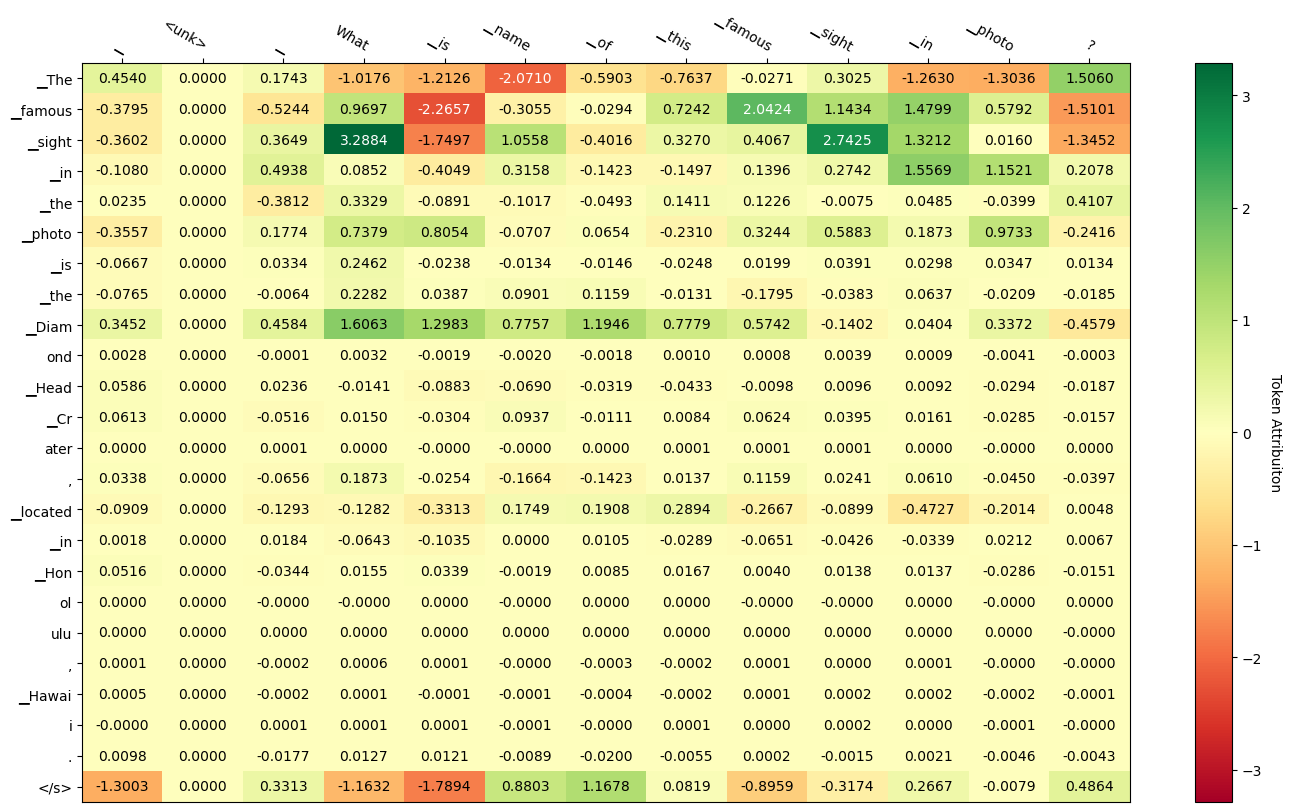

In [14]:
attributions.plot_token_attr(show=True)

#### Interpretability: image

In [27]:
from matplotlib.colors import LinearSegmentedColormap
default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#252b36'),
                                                  (1, '#000000')], N=256)

In [10]:
input_ids

tensor([[    1,   319, 13563,  1546,   263, 12758,  5199,   322,   385, 23116,
         21082, 20255, 29889,   450, 20255,  4076,  8444, 29892, 13173, 29892,
           322,  1248,   568,  6089,   304,   278,  5199, 29915, 29879,  5155,
         29889,  2277, 29937, 29950,  7889, 29901, 29871,  -200, 29871,    13,
          5618,   338,   278,  1024,   310,   445, 13834, 11126,   297,   278,
         15373, 29973,  2277, 29937,  7900, 22137, 29901]], device='cuda:0')

In [9]:
output_ids['sequences']

tensor([[    1,   319, 13563,  1546,   263, 12758,  5199,   322,   385, 23116,
         21082, 20255, 29889,   450, 20255,  4076,  8444, 29892, 13173, 29892,
           322,  1248,   568,  6089,   304,   278,  5199, 29915, 29879,  5155,
         29889,  2277, 29937, 29950,  7889, 29901, 29871,  -200, 29871,    13,
          5618,   338,   278,  1024,   310,   445, 13834, 11126,   297,   278,
         15373, 29973,  2277, 29937,  7900, 22137, 29901,   450, 13834, 11126,
           297,   278, 15373,   338,   278, 22904,   898, 12252,  6781,  1008,
         29892,  5982,   297,  7906,   324, 21528, 29892, 26901, 29875, 29889,
             2]], device='cuda:0')

In [8]:
image_tensor.requires_grad_(True)
input_ids = input_ids.half().requires_grad_(True)

In [9]:
# version with sequences -- 1 tensor with the output_ids

all_attr_vis = []

def forward(img_tensor, input_ids):
    print('input_ids', input_ids)
    print('img_tensor', img_tensor)
    output_ids = model.generate(
        input_ids,
        images=img_tensor[None, :, :, :, :],
        do_sample=do_sample,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        use_cache=use_cache,
        stopping_criteria=[stopping_criteria],
        return_dict_in_generate=True,
        output_scores=True)[0]
    # print('output_ids', output_ids['sequences'])
    # out = torch.stack(output_ids['scores'], dim=0)
    # out = torch.reshape(out, (out.shape[0], out.shape[2]))
    # print('out_scores', out.shape, out.device, out.dtype)
    return output_ids.half()

# out_ids = output_ids['sequences'].clone().half()
# out_ids.requires_grad_(True)

vis_emb = model.get_submodule('model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding')
for idx, out_idx in enumerate(output_ids['sequences'][0]):
    print('Iter: {} -- Looking at {}'.format(idx, out_idx))
    conv = get_conv_template(conv_mode)
    conv.append_message(conv.roles[0], q) # user query
    conv.append_message(conv.roles[1], None) # agent
    lig_vis = LayerIntegratedGradients(forward,
                                       vis_emb,
                                       device_ids=[0])
    # inp = (input_ids, image_tensor)
    # print(inp)
    print('... computing attribution ...')
    attr_vis = lig_vis.attribute(image_tensor,
                                target=out_idx.item(),
                                additional_forward_args=input_ids,
                                return_convergence_delta=True,
                                n_steps=1,
                                method='gausslegendre')
    all_attr_vis.append(attr_vis)

    del lig_vis
    torch.cuda.empty_cache()

Iter: 0 -- Looking at 1
... computing attribution ...
input_ids tensor([[ 1.0000e+00,  3.1900e+02,  1.3560e+04,  1.5460e+03,  2.6300e+02,
          1.2760e+04,  5.2000e+03,  3.2200e+02,  3.8500e+02,  2.3120e+04,
          2.1088e+04,  2.0256e+04,  2.9888e+04,  4.5000e+02,  2.0256e+04,
          4.0760e+03,  8.4480e+03,  2.9888e+04,  1.3176e+04,  2.9888e+04,
          3.2200e+02,  1.2480e+03,  5.6800e+02,  6.0880e+03,  3.0400e+02,
          2.7800e+02,  5.2000e+03,  2.9920e+04,  2.9872e+04,  5.1560e+03,
          2.9888e+04,  2.2760e+03,  2.9936e+04,  2.9952e+04,  7.8880e+03,
          2.9904e+04,  2.9872e+04, -2.0000e+02,  2.9872e+04,  1.3000e+01,
          5.6160e+03,  3.3800e+02,  2.7800e+02,  1.0240e+03,  3.1000e+02,
          4.4500e+02,  1.3832e+04,  1.1128e+04,  2.9700e+02,  2.7800e+02,
          1.5376e+04,  2.9968e+04,  2.2760e+03,  2.9936e+04,  7.9000e+03,
          2.2144e+04,  2.9904e+04]], device='cuda:0', dtype=torch.float16,
       requires_grad=True)
img_tensor tensor([[

TypeError: 'NoneType' object is not iterable

In [ ]:
# version with scores

all_attr_vis = []

def forward(input_ids, img_tensor):
    output_ids = model.generate(
        input_ids,
        images=img_tensor[None, :, :, :, :],
        do_sample=do_sample,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        use_cache=use_cache,
        stopping_criteria=[stopping_criteria],
        return_dict_in_generate=True,
        output_scores=True)#[0]
    
    out = torch.stack(list(output_ids['scores']), dim=0)
    out = out.reshape((out.shape[0], out.shape[2]))

    return out

vis_emb = model.get_submodule('model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding')
for idx, out_idx in enumerate(output_ids['sequences'][0]):
    lig_vis = LayerIntegratedGradients(forward, 
                                       vis_emb, 
                                       device_ids=[0])
    attr_vis = lig_vis.attribute(input_ids,
                                 target=out_idx,
                                 additional_forward_args=image_tensor,
                                 return_convergence_delta=True,
                                 n_steps=1,
                                 method='gausslegendre')
    all_attr_vis.append(attr_vis)

    del lig_vis
    torch.cuda.empty_cache()

In [67]:
# Fix argument passing

def single_output_forward(out_ind):
    def forward(input_ids, img_tensor):
        with torch.inference_mode():
            output_ids = model.generate(
                input_ids,
                images=img_tensor[None, :, :, :, :],
                do_sample=do_sample,
                temperature=temperature,
                max_new_tokens=max_new_tokens,
                use_cache=use_cache,
                stopping_criteria=[stopping_criteria])#[0]
            return output_ids
            # if out_ind < len(output_ids):
            #     return output_ids
            # else:
            #     return None
    return forward

In [ ]:
# Need to do a generation first to know how many indiced to iterate over
# Or, cap it at max_new_tokens.

all_attr_vis = []

vis_emb = model.model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding

for i in range(max_new_tokens):
    conv = get_conv_template(conv_mode)
    conv.append_message(conv.roles[0], q) # user query
    conv.append_message(conv.roles[1], None) # agent
    fwd_fn = single_output_forward(i)
    if fwd_fn is not None:
        lig_vis = LayerIntegratedGradients(fwd_fn, 
                                           vis_emb, 
                                           device_ids=[0])
        out_idx = fwd_fn(input_ids, image_tensor)
        if out_idx is not None:
            print(out_idx)
            # baselines = torch.zeros_like(input_ids)
            # baselines = baselines.to(device='cuda')
            # print(baselines)
            attr_vis = lig_vis.attribute(input_ids,
                                        target=i,
                                        # baselines=baselines,
                                        additional_forward_args = image_tensor,
                                        return_convergence_delta=True,
                                        n_steps=1,
                                        method='gausslegendre')
            all_attr_vis.append(attr_vis)

            # Free up memory
            del lig_vis
            # del baselines
            torch.cuda.empty_cache()
        else:
            # If None is returned, we stop as we are trying to 
            # go beyond the length of the generated sequence.
            break
    else:
        break

In [ ]:
'''import gc
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
            if type(obj):
                print(obj.name, type(obj), obj.size())
    except:
        pass'''

In [ ]:
lig_vis = LayerIntegratedGradients(model, model.model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding)
all_attr_vis = []

for out_idx in output_ids:
    attrib_vis = lig_vis.attribute(input_ids, 
                                   target=out_idx,
                                   baselines=torch.zeros_like(input_ids),
                                   additional_forward_args = image_tensor,
                                   return_convergence_delta=True,
                                   method='gausslegendre')
    all_attr_vis.append(attrib_vis)

In [66]:
input_ids_fix = input_ids.cpu() # fix this, it fucks up with input_ids
input_ids_fix[input_ids_fix<0] = 0
input_ids_fix = input_ids_fix.cuda()
input_ids_fix

tensor([[    1,   319, 13563,  1546,   263, 12758,  5199,   322,   385, 23116,
         21082, 20255, 29889,   450, 20255,  4076,  8444, 29892, 13173, 29892,
           322,  1248,   568,  6089,   304,   278,  5199, 29915, 29879,  5155,
         29889,  2277, 29937, 29950,  7889, 29901, 29871,     0, 29871,    13,
          5618,   338,   278,  1024,   310,   445, 13834, 11126,   297,   278,
         15373, 29973,  2277, 29937,  7900, 22137, 29901]], device='cuda:0')

In [87]:
# Get output
def get_fwd_func(input_ids, image_tensor):
    def forward(input_ids, image_tensor):
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            do_sample=do_sample,
            temperature=temperature,
            max_new_tokens=max_new_tokens,
            use_cache=use_cache,
            stopping_criteria=[stopping_criteria])
        return output_ids
    return forward

fwd_func = get_fwd_func(input_ids, image_tensor)
response = decode_tokens(input_ids, output_ids, tokenizer, stop_str) # if we need it later

In [ ]:
lig_vis = LayerIntegratedGradients(model, model.model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding)
add_args = {
    'images': image_tensor,
    'do_sample': do_sample,
    'temperature': temperature,
    'max_new_tokens': max_new_tokens,
    'use_cache': use_cache,
    'stopping_criteria': [stopping_criteria]
}

add_args2 = (image_tensor, do_sample, temperature, max_new_tokens, use_cache, [stopping_criteria])

inputs = (input_ids_fix, image_tensor)

attrib_vis = lig_vis.attribute(input_ids_fix,method='gausslegendre')

In [ ]:
# Setup (already done above)
# Encode image tensor
# Select the embedding layer
# Get prediction
# Use selected entities as targets

# visualize image attributions
original_im_mat = np.transpose(image_tensor.cpu().detach().numpy())
attributions_img = np.transpose(attributions[0].squeeze(0).cpu().detach().numpy())